# Limit density of the eigenvalues distribution
In this notebook we check that the logic to compute the stieltjes transform is correct. We do that by recovering the density from the stieltjes transform, and comparing that with a sample.  

In [24]:
from typing import Callable

from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.signal import periodogram

# from gpy_test.notebooks.lag_window import lag_window
from gpy_test.covariance import _m  # limit stieltjes transform
from gpy_test.config.fixed_point import FixedPointConfig

sns.set_style("whitegrid")

def inversion_stieltjes(
    s: Callable[[complex], complex], epsilon: float = 1e-6
) -> callable:
    """
    Compute the absolutely continuous density part of the stieltjes transform s.
    """
    return lambda x: np.imag(s(x + 1j * epsilon)) / np.pi

In [29]:
def plot_eig_distribution(N: int, M: int, ar: float, ma: float) -> None: 
    """ 
    Plot the eigenvalue distribution of the sample covariance matrix of a multi-dimensional time series against the limit density.
    The time series is generated as a complex gaussian ARMA(1,1) process.

    Args:
    N: number of samples
    M: dimension of the time series
    ar: AR parameter of the ARMA(1,1) process
    ma: MA parameter of the ARMA(1,1) process

    Returns:
    None
    """
    
    # Generate the sample time series. By assumption it must be the same for all the time series in order to use the GPY test.
    real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag

    # compute the sample covariance matrix and the corresponding eigenvalues
    S = (1 / N) * y.conj().T @ y
    eigs = np.linalg.eigvalsh(S)

    # estimate the spectral density using the lag window estimator
    # use all possible scipy.signal spectral density estimator
    
    # spectral_density = lambda f: np.mean(np.abs(np.fft.fftshift(np.fft.fft(y, axis=0), axes=0)) ** 2, axis=0)
    all_freqs_and_sd_values = periodogram(y, axis=0, return_onesided=False)
    freqs, all_sd_values = all_freqs_and_sd_values[0], all_freqs_and_sd_values[1]
    sd_values = np.mean(all_sd_values, axis=1) # recall that we assume the same time series for all the dimensions

    # reorder freqs and sd_values in ascending order
    idx = np.argsort(freqs)
    freqs = freqs[idx]
    sd_values = sd_values[idx]

    # define the limit density using the fixed point algorithm
    fixed_point = FixedPointConfig(
        init_m_real=1,
        init_m_imag=1,
        max_steps=100,
        tolerance=1e-2,
    )
    c = M / N
    m = lambda z: _m(z, (freqs, sd_values), c, fixed_point)
    density = inversion_stieltjes(m)

    # plot the density against the distribution of eigenvalues of S
    SIZE_FIG = 6
    fig, ax = plt.subplots(figsize=(SIZE_FIG, SIZE_FIG))
    ax.hist(eigs, bins=60, density=True, label="Eigenvalues of $S$")
    x = np.linspace(0, np.max(eigs) * 1.1, 200)
    ax.plot(x, [density(xi) for xi in x], label=r"$p(\lambda)$")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$p(\lambda)$")
    ax.legend()
    ax.set_title(
        f"{N=}, {M=}, {ar=}, {ma=}"
    )
    fig.tight_layout()
    

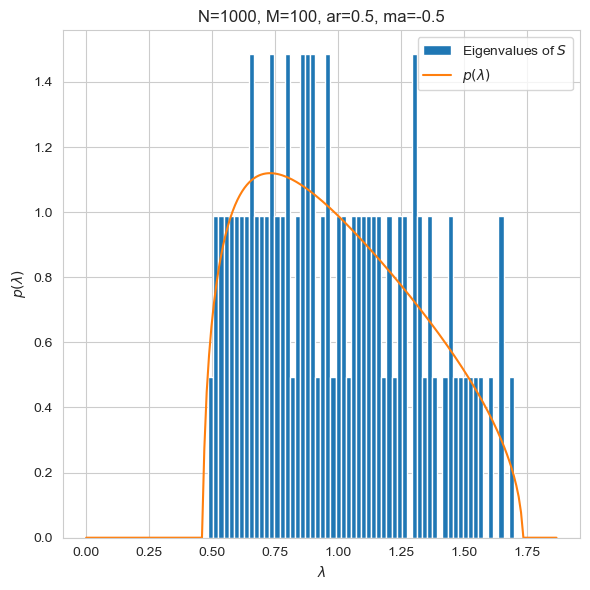

In [30]:
plot_eig_distribution(1000, 100, 0.5, -0.5)

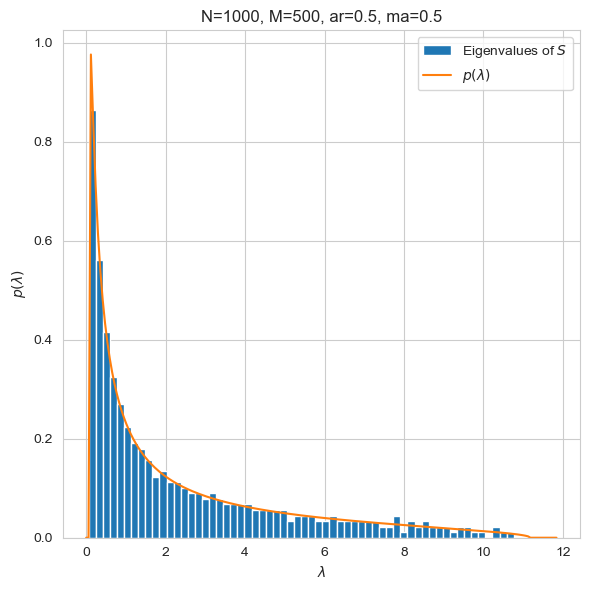

In [31]:
plot_eig_distribution(1000, 500, 0.5, 0.5)

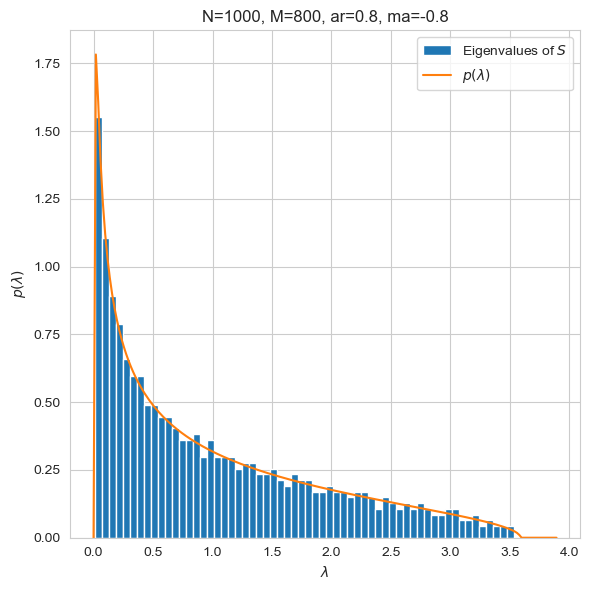

In [32]:
plot_eig_distribution(1000, 800, 0.8, -0.8)